In [419]:
from pathlib import Path
from scipy.stats import chi2_contingency, normaltest, mannwhitneyu
import matplotlib.pyplot as plt
import pandas as pd

In [420]:
# Для отображения числе не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [421]:
project_dir = Path.cwd().parent
data_path = project_dir / 'data' / 'marketplace.csv'
marketplace = pd.read_csv(data_path)
marketplace.head()

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.00,138.78,0.00
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00


In [353]:
marketplace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       25335 non-null  object 
 1   platform_num  25335 non-null  int64  
 2   first_login   25335 non-null  object 
 3   reg_dt        25331 non-null  object 
 4   browser       25335 non-null  object 
 5   first_buy     24361 non-null  object 
 6   target        25335 non-null  float64
 7   total_buy     25335 non-null  float64
 8   total_return  25335 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.7+ MB


In [354]:
marketplace.describe()

,platform_num,target,total_buy,total_return
count,25335.00,25335.00,25335.00,25335.00
mean,6.47,0.00,898.55,334.08
std,17.02,0.25,6815.55,2882.91
min,1.00,-3.43,0.00,0.00
25%,2.00,0.00,19.36,0.00
50%,3.00,0.00,52.72,0.00
75%,6.00,0.00,203.53,0.00
max,674.00,0.30,490447.99,207893.84


## Количество отрицательных значений **target**

In [355]:
marketplace[marketplace["target"] < 0]["target"].count()

np.int64(353)

In [356]:
marketplace[marketplace["target"] > 0]["target"].count()

np.int64(1966)

In [357]:
marketplace["target"].describe()

count   25335.00
mean        0.00
std         0.25
min        -3.43
25%         0.00
50%         0.00
75%         0.00
max         0.30
Name: target, dtype: float64

<Axes: >

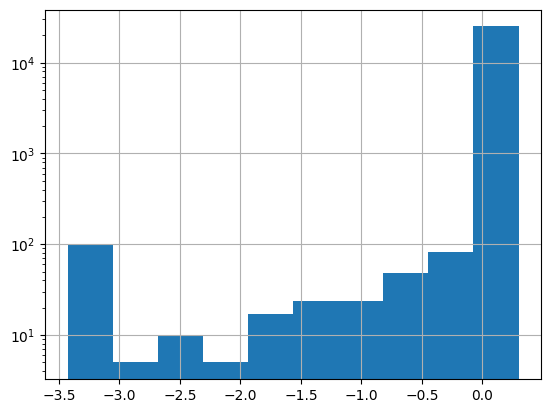

In [358]:
marketplace["target"].hist(log=True)

# Изучение дат

In [422]:
marketplace["first_login"] = pd.to_datetime(marketplace["first_login"])
marketplace["reg_dt"] = pd.to_datetime(marketplace["reg_dt"])
marketplace["first_buy"] = pd.to_datetime(marketplace["first_buy"])
marketplace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


In [360]:
marketplace[
    (marketplace["first_login"] < marketplace["reg_dt"]) | # первый логин раньше регистрации
    (marketplace["first_buy"] < marketplace["first_login"]) | # первая покупка раньше певого логина
    (marketplace["first_buy"] < marketplace["reg_dt"]) # первая покупка раньше регистрации
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 16777 entries, 1 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       16777 non-null  object        
 1   platform_num  16777 non-null  int64         
 2   first_login   16777 non-null  datetime64[ns]
 3   reg_dt        16777 non-null  datetime64[ns]
 4   browser       16777 non-null  object        
 5   first_buy     16640 non-null  datetime64[ns]
 6   target        16777 non-null  float64       
 7   total_buy     16777 non-null  float64       
 8   total_return  16777 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.3+ MB


# Добавление новых признаков датасету для анализа
1. **age_days** - количество дней с первой покупки пользователя
2. **age_group** - разбиение пользователей по группам на основе количества дней с первой покупки
3. **only_returns** - флаг, говорящий о том, что у пользователя нет покупок, только возвраты
4. **return_delta** - разница между возвратами и покупками

In [423]:
today = marketplace["first_buy"].max()
marketplace["age_days"] = (today - marketplace["first_buy"]).dt.days
marketplace["age_days"].describe()

count   24361.00
mean      135.43
std        86.01
min         0.00
25%        85.00
50%       122.00
75%       165.00
max       717.00
Name: age_days, dtype: float64

In [424]:
bins = [0, 85, 122, 165, 717, float("inf")]
labels = ["new", "young", "mid", "mature", "old"]

marketplace["age_group"] = pd.cut(
    marketplace["age_days"],
    bins=bins,
    labels=labels,
    right=False
)
marketplace["age_group"] = marketplace["age_group"].cat.add_categories("inactive")
marketplace.loc[marketplace["first_buy"].isna(), "age_group"] = "inactive"
marketplace["age_group"].describe()

count     25335
unique        6
top         mid
freq       6247
Name: age_group, dtype: object

In [425]:
marketplace["only_returns"] = (marketplace["total_buy"] == 0) & (marketplace["total_return"] > 0)
marketplace["only_returns"].describe()

count     25335
unique        2
top       False
freq      25183
Name: only_returns, dtype: object

In [426]:
def calc_return_delta(row):
    buy = row["total_buy"]
    ret = row["total_return"]
    return ret - buy

marketplace["return_delta"] = marketplace.apply(calc_return_delta, axis=1)
marketplace["return_delta"].describe()

count     25335.00
mean       -564.47
std        4436.09
min     -282554.15
25%        -153.90
50%         -41.69
75%         -14.56
max       30585.52
Name: return_delta, dtype: float64

# Выделим группу пользователей генерирующих убытки
- если **return_delta** > 0, значит количество возвратов превышает покупки

In [455]:
df_high_returns = marketplace[marketplace["return_delta"] > 0].copy()
df_high_returns.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days,return_delta
count,1981.00,1981,1981,1918,1981.00,1981.00,1981.00,1918.00,1981.00
mean,6.60,2025-02-22 11:29:50.005047808,2024-11-05 10:17:52.185764864,2025-02-12 15:57:59.874869760,-0.03,382.53,634.51,162.33,251.97
min,1.00,2024-09-21 00:00:00,2022-10-11 00:00:00,2023-10-20 00:00:00,-3.43,0.00,21.39,5.00,0.08
25%,2.00,2025-01-19 00:00:00,2024-09-17 00:00:00,2025-01-19 00:00:00,0.00,14.00,49.00,115.00,26.06
50%,4.00,2025-03-08 00:00:00,2025-01-29 00:00:00,2025-03-09 00:00:00,0.00,52.85,132.37,138.00,58.98
75%,7.00,2025-03-31 00:00:00,2025-03-18 00:00:00,2025-04-01 00:00:00,0.00,174.98,400.00,187.00,162.83
max,330.00,2025-07-21 00:00:00,2025-07-23 00:00:00,2025-07-20 00:00:00,0.30,50385.13,59935.22,644.00,30585.52
std,14.44,NaN,NaN,NaN,0.40,1754.85,2341.87,97.12,973.82


# Анализ пользователей у которых есть только возрвраты

In [431]:
df_with_returns = pd.DataFrame(marketplace[marketplace["only_returns"]])
df_with_returns.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days,return_delta
count,152.00,152,152,151,152.00,152.00,152.00,151.00,152.00
mean,4.86,2025-02-09 23:03:09.473684224,2025-01-19 21:18:56.842105344,2025-01-31 17:57:36.953642496,-0.02,0.00,104.23,174.25,104.23
min,1.00,2024-10-13 00:00:00,2024-01-07 00:00:00,2024-01-10 00:00:00,-3.43,0.00,21.99,15.00,21.99
25%,2.00,2025-01-20 00:00:00,2025-01-10 00:00:00,2025-01-19 00:00:00,0.00,0.00,24.08,136.50,24.08
50%,3.00,2025-02-09 00:00:00,2025-02-09 12:00:00,2025-02-14 00:00:00,0.00,0.00,37.01,161.00,37.01
75%,5.25,2025-03-07 00:00:00,2025-03-08 12:00:00,2025-03-10 12:00:00,0.00,0.00,59.54,187.00,59.54
max,56.00,2025-07-19 00:00:00,2025-07-17 00:00:00,2025-07-10 00:00:00,0.30,0.00,3272.02,562.00,3272.02
std,6.09,NaN,NaN,NaN,0.28,0.00,347.08,86.75,347.08


In [366]:
df_with_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 115 to 24672
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       152 non-null    object        
 1   platform_num  152 non-null    int64         
 2   first_login   152 non-null    datetime64[ns]
 3   reg_dt        152 non-null    datetime64[ns]
 4   browser       152 non-null    object        
 5   first_buy     151 non-null    datetime64[ns]
 6   target        152 non-null    float64       
 7   total_buy     152 non-null    float64       
 8   total_return  152 non-null    float64       
 9   age_days      151 non-null    float64       
 10  age_group     152 non-null    category      
 11  only_returns  152 non-null    bool          
dtypes: bool(1), category(1), datetime64[ns](3), float64(4), int64(1), object(2)
memory usage: 13.6+ KB


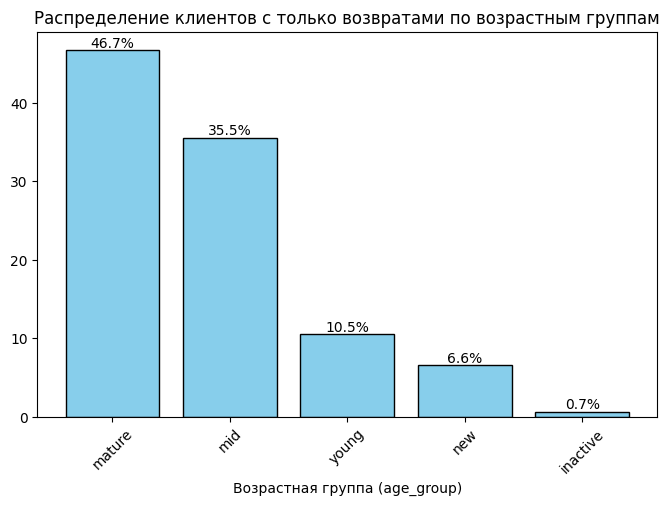

In [406]:
returns_by_age_group = df_with_returns.groupby("age_group", observed=True)[
    "user_id"].count() / df_with_returns["user_id"].count() * 100

returns_by_age_group = returns_by_age_group.sort_values(
    ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns_by_age_group.index,
              returns_by_age_group.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_xlabel("Возрастная группа (age_group)")
ax.set_title("Распределение клиентов с только возвратами по возрастным группам")
plt.xticks(rotation=45)
plt.show()

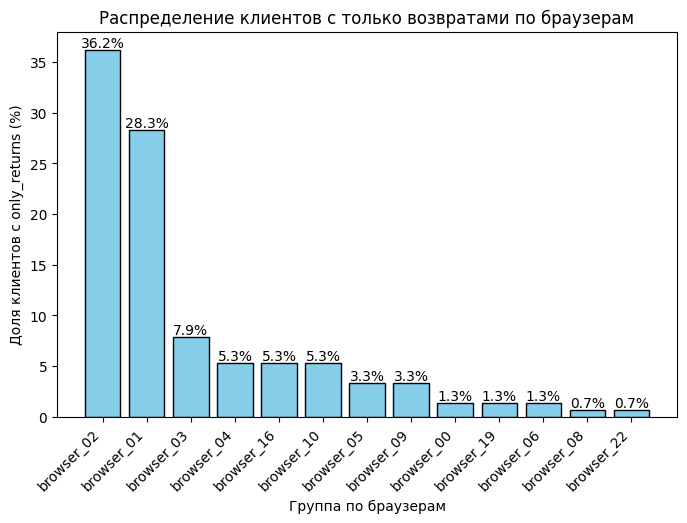

In [405]:
returns_by_browser = df_with_returns.groupby("browser", observed=True)[
    "user_id"].count() / df_with_returns["user_id"].count() * 100

returns_by_browser = returns_by_browser.sort_values(
    ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns_by_browser.index,
              returns_by_browser.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_xlabel("Группа по браузерам")
ax.set_title("Распределение клиентов с только возвратами по браузерам")
plt.xticks(rotation=45, ha='right')
plt.show()

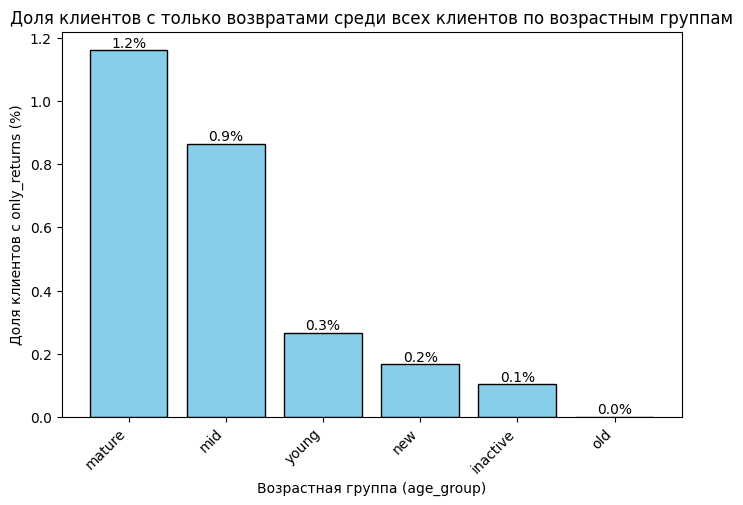

In [ ]:
only_returns_in_all_by_browser = marketplace.groupby("age_group", observed=True)[
    "only_returns"].mean() * 100

only_returns_in_all_by_browser = only_returns_in_all_by_browser.sort_values(
    ascending=False).head(13)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(only_returns_in_all_by_browser.index,
              only_returns_in_all_by_browser.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_ylabel("Доля клиентов с only_returns (%)")
ax.set_xlabel("Возрастная группа (age_group)")
ax.set_title(
    "Доля клиентов с только возвратами среди всех клиентов по возрастным группам")
plt.xticks(rotation=45, ha='right')
plt.show()

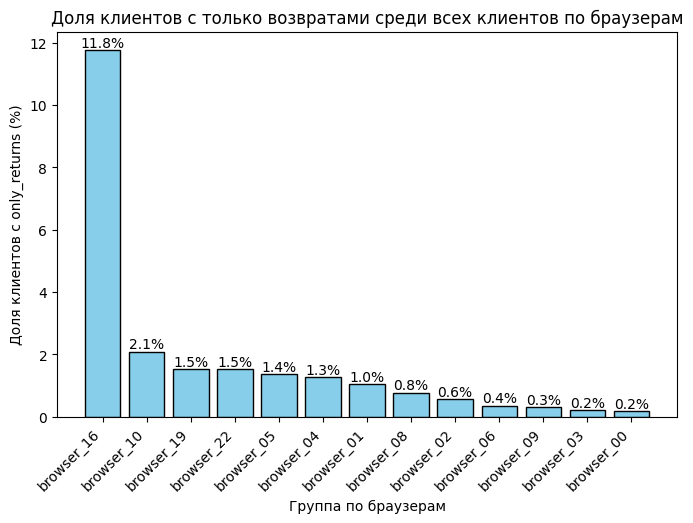

In [412]:
only_returns_in_all_by_browser = marketplace.groupby("browser", observed=True)[
    "only_returns"].mean() * 100

only_returns_in_all_by_browser = only_returns_in_all_by_browser.sort_values(
    ascending=False).head(13)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(only_returns_in_all_by_browser.index,
              only_returns_in_all_by_browser.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_ylabel("Доля клиентов с only_returns (%)")
ax.set_xlabel("Группа по браузерам")
ax.set_title("Доля клиентов с только возвратами среди всех клиентов по браузерам")
plt.xticks(rotation=45, ha='right')
plt.show()

# Изучение признака platform_num

In [441]:
marketplace[marketplace["platform_num"] == marketplace["platform_num"].max()]

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,age_days,age_group,only_returns,return_delta
1927,user_001925,674,2024-11-12,2024-07-25,browser_03,2024-08-03,0.30,45877.83,24302.00,356.00,mature,False,-21575.83


In [442]:
marketplace.sort_values("platform_num", ascending=False).head(10)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,age_days,age_group,only_returns,return_delta
1927,user_001925,674,2024-11-12,2024-07-25,browser_03,2024-08-03,0.30,45877.83,24302.00,356.00,mature,False,-21575.83
14553,user_014550,647,2024-10-02,2024-09-05,browser_03,2024-09-21,-0.00,15754.61,10643.36,307.00,mature,False,-5111.25
3067,user_003065,542,2024-10-11,2024-07-26,browser_02,2024-09-15,0.10,66582.73,20983.01,313.00,mature,False,-45599.72
18597,user_018594,540,2024-12-14,2024-12-01,browser_03,2024-11-26,0.30,18992.27,10651.05,241.00,mature,False,-8341.23
17874,user_017871,475,2024-11-02,2024-10-31,browser_03,2024-12-09,0.22,20179.29,4050.00,228.00,mature,False,-16129.29
10881,user_010878,399,2025-03-30,2024-01-27,browser_03,2025-03-16,0.30,5364.42,2498.61,131.00,mid,False,-2865.81
7787,user_007784,391,2024-12-05,2024-12-09,browser_06,2024-12-15,-2.03,3425.46,2120.53,222.00,mature,False,-1304.93
15114,user_015111,380,2024-10-02,2024-06-17,browser_03,2024-09-24,0.30,15981.50,0.00,304.00,mature,False,-15981.50
435,user_000433,358,2024-10-02,2024-10-03,browser_03,2024-09-29,0.00,5073.51,3175.00,299.00,mature,False,-1898.51
12776,user_012773,352,2025-03-22,2022-12-28,browser_03,2025-03-16,0.00,9723.93,9682.00,131.00,mid,False,-41.93


Топ-10 по количеству устройств выглядит неестественным.
### Список гипотез:
- Гипотеза А: технический баг:\
Количество устройств считается неправильно
- Гипотеза B: мошеннические аккаунты
- Гипотеза C: коллективные аккаунты

# Проверка гипотезы о том, что **return_delta** будет выше в группе с высоким показателем **platform_num**
- Оценим нормальность распределения **platform_num** в обеих группах
- Выберем тест для проверки гипотезы: t-тест для нормального распределения, Mann-Whitney U тест для другого

In [446]:
platfrom_threshold = marketplace["platform_num"].quantile(0.9)
df_with_large_platform_num = pd.DataFrame(
    marketplace[marketplace["platform_num"] > platfrom_threshold]
)
df_with_usual_platfrom_num = pd.DataFrame(
    marketplace[marketplace["platform_num"] <= platfrom_threshold]
)
df_with_large_platform_num.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days,return_delta
count,2440.00,2440,2440,2434,2440.00,2440.00,2440.00,2434.00,2440.00
mean,34.39,2025-01-19 09:26:33.442622976,2024-09-25 15:56:39.344262144,2025-01-09 12:44:22.284305664,0.02,2971.22,1159.02,196.47,-1812.21
min,13.00,2024-09-21 00:00:00,2022-10-14 00:00:00,2023-08-12 00:00:00,-3.43,0.00,0.00,4.00,-282554.15
25%,15.00,2024-11-14 00:00:00,2024-07-30 00:00:00,2024-11-17 00:00:00,0.00,52.99,0.00,122.00,-834.07
50%,21.00,2025-01-29 00:00:00,2024-11-17 00:00:00,2025-02-03 00:00:00,0.00,215.58,0.00,172.00,-151.34
75%,34.00,2025-03-22 00:00:00,2025-02-07 00:00:00,2025-03-25 00:00:00,0.00,1209.19,280.00,250.00,-32.45
max,674.00,2025-07-19 00:00:00,2025-07-19 00:00:00,2025-07-21 00:00:00,0.30,490447.99,207893.84,713.00,30585.52
std,45.58,NaN,NaN,NaN,0.30,14660.81,6224.78,103.43,9095.87


In [ ]:
stat, p = normaltest(df_with_usual_platfrom_num["return_delta"])
print(f"Normal test p-value для всей выборки: {p:.3g}")
stat, p = normaltest(df_with_large_platform_num["return_delta"])
print(f"Normal test p-value для выборки с большим количеством устройств: {p:.3g}")

Normal test p-value для всей выборки: 0
Normal test p-value для выборки с большим количеством устройств: 0


Выбираем Манна-Уитни тест:\
H<sub>0</sub>: распределение **return_delta** одинаково для всех пользователей\
H<sub>1</sub>: пользователи с большим числом платформ чаще генерируют убытки

In [452]:
stat, p = mannwhitneyu(
    df_with_large_platform_num["return_delta"],
    df_with_usual_platfrom_num["return_delta"], 
    alternative='greater'
)
print("Гипотезу 0 принимаем" if p > 0.05 else "Гипотезу 0 отвергаем")
print(f"Манна-Уитни U-statistic: {stat:.2f}, p-value: {p:.3g}")

Гипотезу 0 принимаем
Манна-Уитни U-statistic: 18537108.00, p-value: 1


Статистически нет доказательств, что пользователи с большим числом платформ генерируют больше убытков.

# Поиск фродовых каналов у клиентов с большим ***platform_num*** и высоким **return_delta**
Сравним распределение категориального признака ***browser*** между двумя независимыми группами:
1. Пользователи с ***platform_num*** > 90-го перцентиля среди пользователей с высоким **return_delta**
2. Все остальные

Используем критерий χ², чтобы оценить насколько сильно отличаются частоты категорий.\
H<sub>0</sub>: Распределение браузеров одинаково в обеих группах\
H<sub>1</sub>: Распределение браузеров отличается\
Уровень значимости α = 0.05

Если принимаем гипотезу H<sub>1</sub> - есть аномальные каналы связи по которым приходят боты.

In [456]:
marketplace["browser"] = marketplace["browser"].astype("category")
df_high_returns["browser"] = df_high_returns["browser"].astype("category")

threshold = marketplace["platform_num"].quantile(0.9)

df_large = df_high_returns[df_high_returns["platform_num"] > threshold]
df_all = marketplace.copy()
contingency = pd.crosstab(
    df_all["browser"],
    df_all.index.isin(df_large.index)
)
chi2, p, dof, expected = chi2_contingency(contingency)
print("Гипотезу 0 принимаем" if p > 0.05 else "Гипотезу 0 отвергаем")
print(f"p-value: {p:.3g}")

Гипотезу 0 принимаем
p-value: 0.0698


Статистически значимых аномалий по браузерам не выявлено

# Проверка, что в выборке с высоким **return_delta** не присутствуют специфичные браузеры
- Посмотрим как браузеры распределены в исходной выборке
- Обозначим как редкие браузеры, которыми пользуется меньше 50% выборки
- Сравним, чаще ли редкие браузеры встречаются в выборке клиентов с высокой долей возвратов\
H<sub>0</sub>: Редкие браузеры встречаются одинаково часто\
H<sub>1</sub>: Редкие браузеры встречаются чаще в выборке с высоким **return_delta**

In [464]:
marketplace['browser'].value_counts().describe()

count     31.00
mean     817.26
std     2039.13
min        1.00
25%        5.50
50%       68.00
75%      374.00
max     9500.00
Name: count, dtype: float64

In [467]:
counts = marketplace['browser'].value_counts()
threshold = counts.quantile(0.5)
rare_browsers = counts[counts < threshold].index

marketplace['is_rare_browser'] = marketplace['browser'].isin(rare_browsers)

platform_threshold = marketplace["platform_num"].quantile(0.9)

df_high_returns['is_rare_browser'] = df_high_returns['browser'].isin(rare_browsers)

contingency = pd.crosstab(
    marketplace['is_rare_browser'],
    marketplace.index.isin(df_high_returns.index)
)

chi2, p, dof, expected = chi2_contingency(contingency)
print("Гипотезу 0 принимаем" if p > 0.05 else "Гипотезу 0 отвергаем")
print(f"p-value: {p:.3g}")


Гипотезу 0 принимаем
p-value: 0.0991


Статистически значимых различий между долей редких браузеров в выборке с высокими возвратами и в общей выборке нет.

# Распределение **return_delta** по возрастным группам

In [469]:
marketplace.groupby("age_group", observed=True)["return_delta"].mean().sort_values()

age_group
young      -739.97
mature     -718.74
inactive   -612.04
mid        -578.46
new        -209.99
old        -208.42
Name: return_delta, dtype: float64

В среднем все группы пользователей по возрастным группам не убыточны, но меньше всего прибыли генерируют **new** и **old**

In [472]:
df_high_returns.groupby("age_group", observed=True)["return_delta"].mean().sort_values(ascending=False)

age_group
inactive   723.84
young      299.26
new        237.78
mature     230.26
mid        203.10
Name: return_delta, dtype: float64

Среди пользователей с самым высоким уровнем возвратов преобладают **yong** и **new**.\
**inactive** считаем как аномалию, потому что это пользователи у которых нет покупок в этом срезе

# Добавим новые признаки **return_per_date** и **buy_per_date**
Прибавим к дням 1, чтобы избежать деления на 0. Считаем, что пользователь с нулём дней всё купил и вернул за 1 день.

In [473]:
marketplace["return_per_date"] = marketplace["total_return"] / (marketplace["age_days"] + 1)
marketplace["buy_per_date"] = marketplace["total_buy"] / (marketplace["age_days"] + 1)
df_high_returns["return_per_date"] = df_high_returns["total_return"] / (df_high_returns["age_days"] + 1)
df_high_returns["buy_per_date"] = df_high_returns["total_buy"] / (df_high_returns["age_days"] + 1)

In [476]:
marketplace.groupby("age_group", observed=True)["return_per_date"].mean().sort_values(ascending=False)

age_group
young      3.07
mid        2.64
mature     1.69
new        1.54
old        1.34
inactive    NaN
Name: return_per_date, dtype: float64

In [477]:
marketplace.groupby("age_group", observed=True)["buy_per_date"].mean().sort_values()

age_group
old        1.63
mature     4.16
new        6.95
mid        7.02
young      9.70
inactive    NaN
Name: buy_per_date, dtype: float64

In [ ]:
marketplace.groupby("age_group", observed=True)["return_per_date"].mean(
) / marketplace.groupby("age_group", observed=True)["buy_per_date"].mean()

age_group
new        0.22
young      0.32
mid        0.38
mature     0.41
old        0.82
inactive    NaN
dtype: float64

In [478]:
df_high_returns.groupby("age_group", observed=True)["return_per_date"].mean().sort_values(ascending=False)

age_group
new        10.04
young       6.41
mid         4.73
mature      1.61
inactive     NaN
Name: return_per_date, dtype: float64

In [ ]:
df_high_returns.groupby("age_group", observed=True)["buy_per_date"].mean().sort_values()

age_group
mature     0.82
mid        3.22
young      3.76
new        5.00
inactive    NaN
Name: buy_per_date, dtype: float64

In [ ]:
df_high_returns.groupby("age_group", observed=True)["return_per_date"].mean(
) / df_high_returns.groupby("age_group", observed=True)["buy_per_date"].mean()

age_group
new        2.01
young      1.70
mid        1.47
mature     1.96
inactive    NaN
dtype: float64

# TO DO LIST:
* Оценить признаки return_per_date, buy_per_date